# Optimizing Bakery Operations through Association Rule Mining and Transactional Analytics

## Loading Library

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    module="jupyter_client.session"
)


!pip install mlxtend==0.23.1

# **A Day in the Life of a Data Analyst: Unraveling Insights from The Bread Basket Dataset**

---

**Thursday, December 5** <br>
As the sun rises on another busy Thursday, I settle into my workspace, ready to dive into The Bread Basket dataset. This dataset is a treasure trove of information, capturing the essence of customer transactions at a local bakery. My goal today is to uncover insights that can help the bakery optimize its offerings and enhance customer satisfaction.


## **Loading Dataset**
I start my day by loading the dataset into my Python environment. Yesterday, I got the dataset from my [Client](https://raw.githubusercontent.com/NathaliaMinoque/datasets/refs/heads/main/bread%20basket%20(1).csv). Using Pandas, I import the data and take a moment to familiarize myself with its structure.

In [2]:
#1
df = pd.read_csv("https://raw.githubusercontent.com/royhandaus/data_mining_royhan/refs/heads/main/Coffee%20Shop%20Operation%20/Dataset/bread%20basket%20(1).csv")
df.head()

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,30-10-2016 09:58,morning,weekend
1,2,Scandinavian,30-10-2016 10:05,morning,weekend
2,2,Scandinavian,30-10-2016 10:05,morning,weekend
3,3,Hot chocolate,30-10-2016 10:07,morning,weekend
4,3,Jam,30-10-2016 10:07,morning,weekend


As I glance through the initial rows, I see the columns: Transaction, Item, date_time, period_day, and weekday_weekend. Each transaction is unique, and I can already sense the potential insights hidden within.

## **Exploratory Data Analysis (EDA)**
With the dataset loaded, I transition into Exploratory Data Analysis (EDA). This phase is crucial for understanding the data better and identifying patterns.
### **Data Overview**
I begin by checking for missing values and summarizing the basic statistics of the dataset.

In [3]:
#2 info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Transaction      20507 non-null  int64 
 1   Item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   period_day       20507 non-null  object
 4   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(4)
memory usage: 801.2+ KB


In [4]:
#3 check missing values
print(df.isnull().sum())

Transaction        0
Item               0
date_time          0
period_day         0
weekday_weekend    0
dtype: int64


4. The overview reveals a ________ . (fill that blank on the section below)

dataset is clean (no null) also there is 5 column with 20507 data

### **Transaction Trends**
Next, I analyze transaction trends over time. I extract the date and hour from the date_time column to see how customer purchases vary throughout the day and week. Then, I visualize the daily transaction trends to identify peak days and times for customer activity.

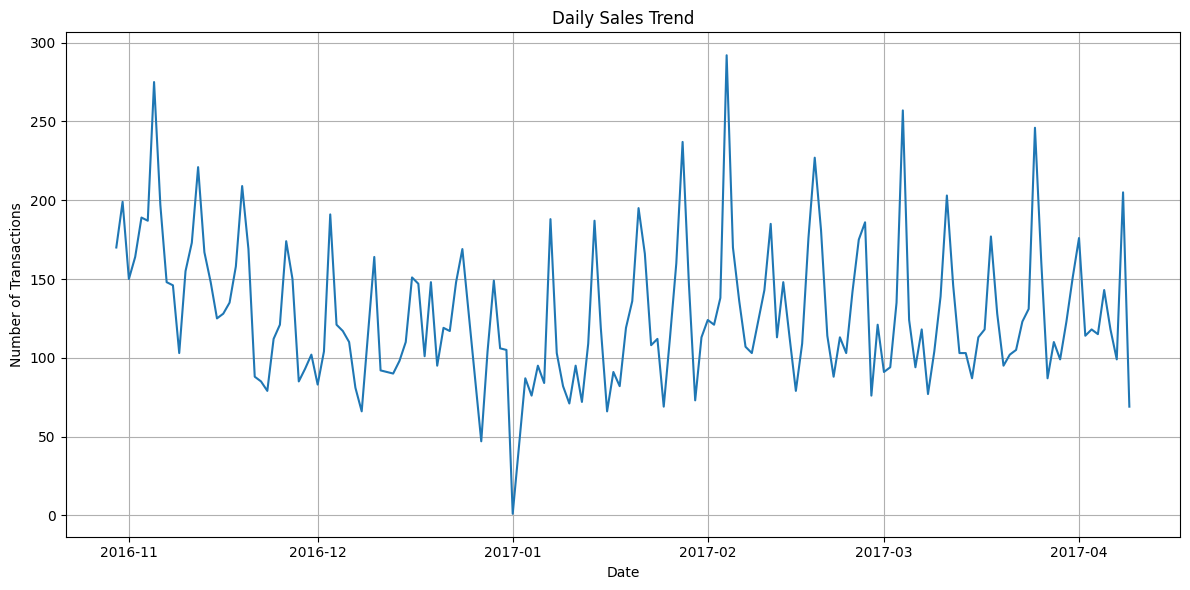

In [5]:
# 5
df['date_time'] = pd.to_datetime(df['date_time'], format='%d-%m-%Y %H:%M')
daily_transactions = df.groupby(df['date_time'].dt.date)['Transaction'].count()

plt.figure(figsize=(12, 6))
daily_transactions.plot(kind='line')
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.tight_layout()
plt.show()


Oh my God, it's so difficult to get insights from this visualization, but it seems like there might be a trend to uncover. Let me try separating it by the perspective of hour, time, day, day_name, month, and year by adding each of those variabels into the dataframe.

In [6]:
# 6
df['day'] = df['date_time'].dt.day
df['month'] = df['date_time'].dt.month
df['year'] = df['date_time'].dt.year
df['time'] = df['date_time'].dt.time
df['hour'] = df['date_time'].dt.hour
df['day_name'] = df['date_time'].dt.day_name()
df.sample(5)

,Transaction,Item,date_time,period_day,weekday_weekend,day,month,year,time,hour,day_name
383,185,Tea,2016-11-01 09:29:00,morning,weekday,1,11,2016,09:29:00,9,Tuesday
3117,1518,Bread,2016-11-17 13:21:00,afternoon,weekday,17,11,2016,13:21:00,13,Thursday
17940,8521,Coffee,2017-03-21 11:18:00,morning,weekday,21,3,2017,11:18:00,11,Tuesday
14812,7121,Chicken Stew,2017-02-24 14:35:00,afternoon,weekday,24,2,2017,14:35:00,14,Friday
6652,3340,Coffee,2016-12-17 11:48:00,morning,weekend,17,12,2016,11:48:00,11,Saturday



Alright, now I can easily create a visualization of monthly sales.

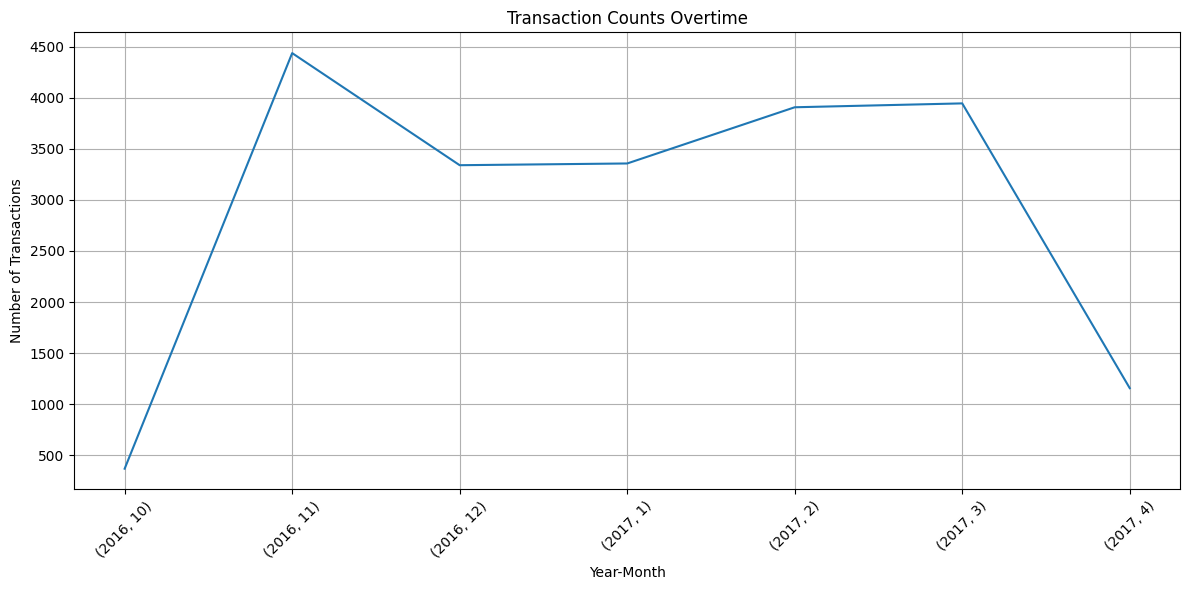

In [7]:
# 7
monthly_transactions = df.groupby(['year', 'month']).size()

plt.figure(figsize=(12, 6))
monthly_transactions.plot(kind='line')
plt.title('Transaction Counts Overtime')
plt.xlabel('Year-Month')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


8. Now, the visualization above provides better insights: ___________ . (fill that blank on the section below)

From the monthly sales trend visualization, we can observe that the data begins in October 2016 with relatively low transactions, followed by a significant surge in November 2016, which is the highest peak. Transactions remain robust from December 2016 through March 2017, suggesting a steady customer base during these months, possibly indicating strong holiday and post-holiday sales. However, there's a notable decline in April 2017, which might be due to the dataset ending, or a seasonal dip.

Next, I want to see if there's a trend for each day of the week in each month.
Oh, the dataframe has a column called weekday_weekend. What days include weekends and weekdays??

In [8]:
#9
unique_weekday_names = df[df['weekday_weekend'] == 'weekday']['day_name'].unique()
unique_weekend_names = df[df['weekday_weekend'] == 'weekend']['day_name'].unique()

print(f"Unique weekday names: {unique_weekday_names}")
print(f"Unique weekend names: {unique_weekend_names}")

Unique weekday names: ['Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday']
Unique weekend names: ['Sunday' 'Saturday']



Oh, okay, now I know that "weekend" refers to Sunday and Saturday. Alright, moving on, before creating the visualization, it seems necessary to create an aggregation with the columns for the month and day name, where the values represent the total transactions that occurred.

In [9]:
#10
daily_monthly_transactions = df.groupby(['month', 'day_name'])['Transaction'].count().unstack(fill_value=0)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_monthly_transactions = daily_monthly_transactions.reindex(columns=day_order, fill_value=0)
display(daily_monthly_transactions)

day_name,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
month,,,,,,,
1,329,474,322,399,489,807,536
2,474,429,419,456,599,879,650
3,379,433,459,557,674,883,559
4,118,115,143,118,99,381,183
10,199,0,0,0,0,0,170
11,469,599,576,591,639,879,683
12,356,342,402,525,624,776,314


11. Wow, it turns out the insight that can be gained from the table above is _____

- Weekend Popularity: Saturdays and Sundays consistently show the highest number of transactions across all months, indicating that these are the busiest days for the bakery.
- Weekday Trends: Fridays also tend to have higher transaction counts compared to other weekdays (Monday to Thursday).
- Monthly Variations: November appears to be a particularly strong month with high transaction volumes, while April shows a significant decline in sales across all days of the week.
- Relative Consistency: Among the weekdays (Monday-Thursday), transaction counts are relatively stable, though considerably lower than on weekends or Fridays.






It seems ready to create the visualization now. Okay, I will create a comparison visualization of total sales per day for each month.

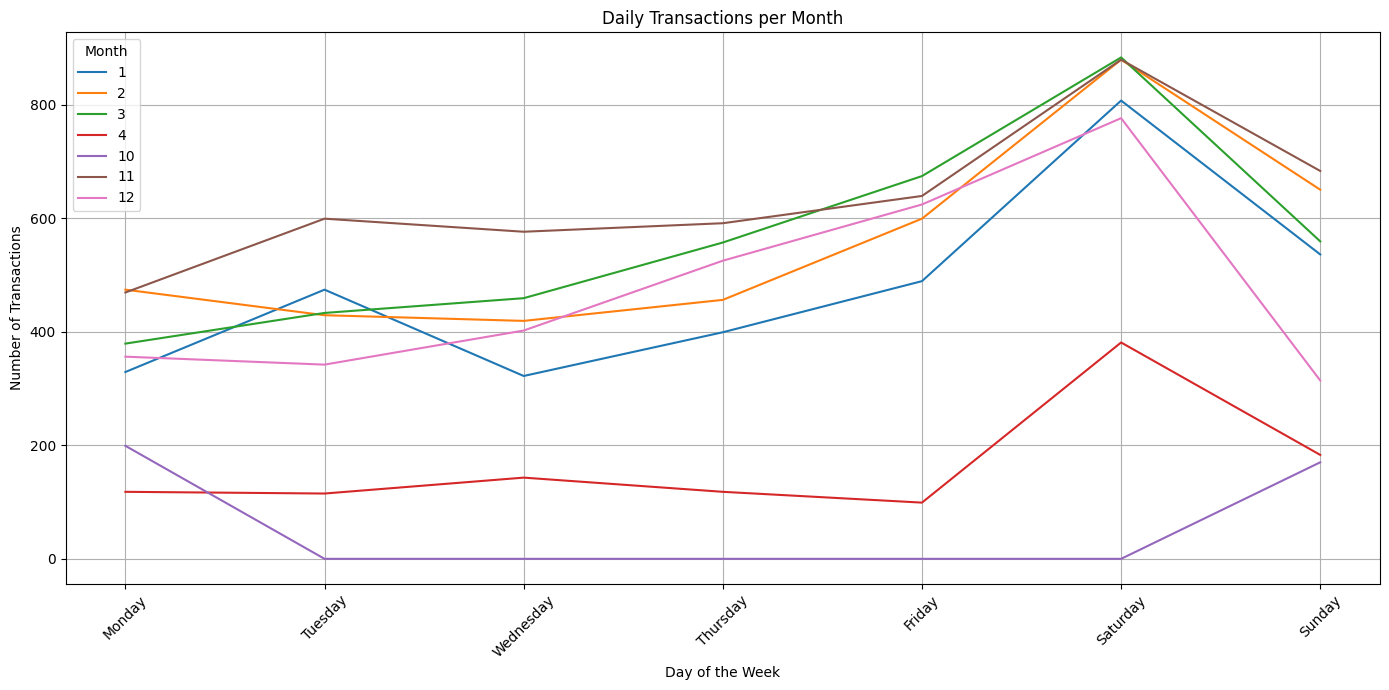

In [10]:
#12
plt.figure(figsize=(14, 7))
daily_monthly_transactions.T.plot(kind='line', ax=plt.gca())

plt.title('Daily Transactions per Month')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Month')
plt.tight_layout()
plt.show()

13. Wow, after visualizing it like this, I can gain insights into the sales trends that ____.

From this line chart, several insights into sales trends become clear:

- Consistent Weekend Peaks: Across almost all months, Saturday consistently shows the highest transaction volume, followed closely by Sunday. This reinforces that weekends are the primary business drivers.
- Weekday Variance: There's a noticeable pattern in weekday sales: Mondays and Tuesdays tend to be lower, with a gradual increase towards Friday. Fridays often show a significant bump, acting as a bridge to the weekend rush.
- Monthly Performance Differences: The chart clearly separates months by their overall transaction levels. For instance, November and December (and early 2017 months like January, February, March) show higher lines across all days, indicating generally higher sales periods. In contrast, October (the partial month) and April show significantly lower lines, especially April, which has the lowest transaction counts across all days.
- Relative Shape Consistency: Despite varying overall volumes, the shape of the weekly trend (low early week, rising to Friday, peak on Saturday/Sunday) remains largely consistent across months with similar activity levels, suggesting a stable customer purchasing pattern.
- April's Decline: The steep drop in transaction numbers for April across all days is very prominent, confirming the observation from the monthly sales trend that April was a slow month or represented the end of the dataset.

Oh, it turns out there's also a "period_day" column in the dataframe, but at the beginning, I only noticed "morning." Hmm, I'm curious, what other unique values could there be?

In [11]:
# 14
df['period_day'].unique()

array(['morning', 'afternoon', 'evening', 'night'], dtype=object)

Oh, okay, there are "morning," "afternoon," "evening," and "night."
But, but, but, what are the time ranges for morning, afternoon, evening, and night? Let me try to find out.

In [12]:
# 15
unique_morning_hour = df[df['period_day'] == 'morning']['hour'].unique()
unique_afternoon_hour = df[df['period_day'] == 'afternoon']['hour'].unique()
unique_evening_hour = df[df['period_day'] == 'evening']['hour'].unique()
unique_night_hour = df[df['period_day'] == 'night']['hour'].unique()

print(f"Unique morning_hour: {unique_morning_hour}")
print(f"Unique afternoon_hour: {unique_afternoon_hour}")
print(f"Unique evening_hour: {unique_evening_hour}")
print(f"Unique night_hour: {unique_night_hour}")

Unique morning_hour: [ 9 10 11  8  7  1]
Unique afternoon_hour: [12 13 14 15 16]
Unique evening_hour: [17 18 19 20]
Unique night_hour: [21 23 22]


16. Hah, I found something odd in the results above. Did you notice it too? What do you think is odd about it and why?

Beyond the 1 AM in the 'morning' period, which is quite unusual, the other time periods ('afternoon', 'evening', and 'night') appear to have more contiguous and expected hourly ranges. For example:

- Afternoon spans from 12 PM to 4 PM (16:00), which is a common understanding of afternoon.
- Evening covers 5 PM to 8 PM (17:00 to 20:00), also a typical evening window.
- Night starts from 9 PM to 11 PM (21:00 to 23:00). It's notable that there are - no transactions recorded for 00:00 (midnight) in any category, suggesting the bakery might not be open then, or the dataset doesn't capture those hours.

So, while the other periods are relatively consistent, the 'morning' period remains the most fragmented and includes an hour that usually falls into 'night'.


But that's okay, I'll just continue exploring the insights. It seems like I can create a sales analysis based on the hours of each day here.

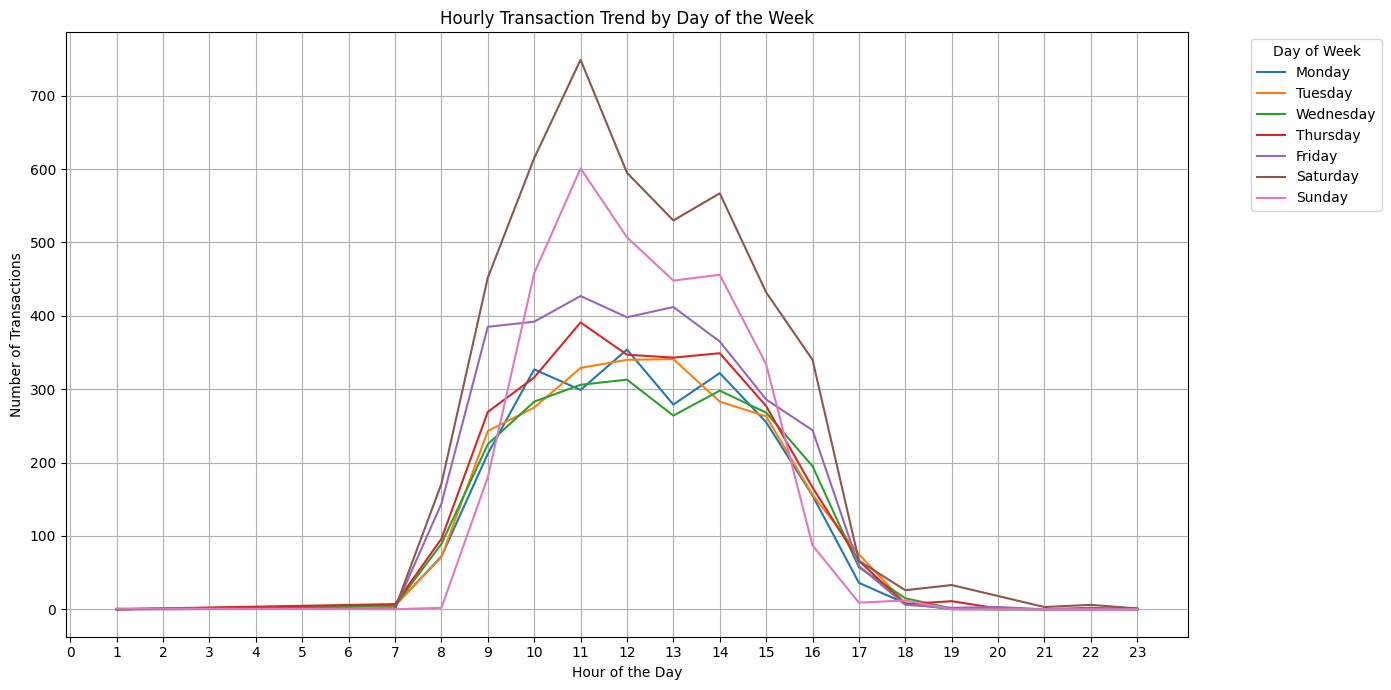

In [13]:
#17
hourly_transactions_by_day = df.groupby(['hour', 'day_name'])['Transaction'].count().unstack(fill_value=0)

# Ensure the columns (day names) are in the correct order for consistent plotting
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
hourly_transactions_by_day = hourly_transactions_by_day.reindex(columns=day_order, fill_value=0)

plt.figure(figsize=(14, 7))
hourly_transactions_by_day.plot(kind='line', ax=plt.gca()) # Removed marker='o'

plt.title('Hourly Transaction Trend by Day of the Week')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Transactions')
plt.xticks(range(0, 24)) # Set x-ticks to display all hours from 0 to 23
plt.grid(True)
plt.legend(title='Day of Week', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

18. The daily sales trend plot reveals that ___________

The 'Hourly Transaction Trend by Day of the Week' plot reveals that transactions consistently peak between 10 AM and 12 PM across most days. Weekends, particularly Saturdays, show significantly higher transaction volumes throughout the day. Weekdays follow a similar pattern, with a gradual increase from morning, peaking around midday, and then declining in the afternoon. The bakery's operational hours, as indicated by transaction data, primarily span from 7 AM to 8 PM, with minimal activity outside this window.

### **Item Popularity**
Curious about which items are most popular, I analyze the frequency of orders for each item.

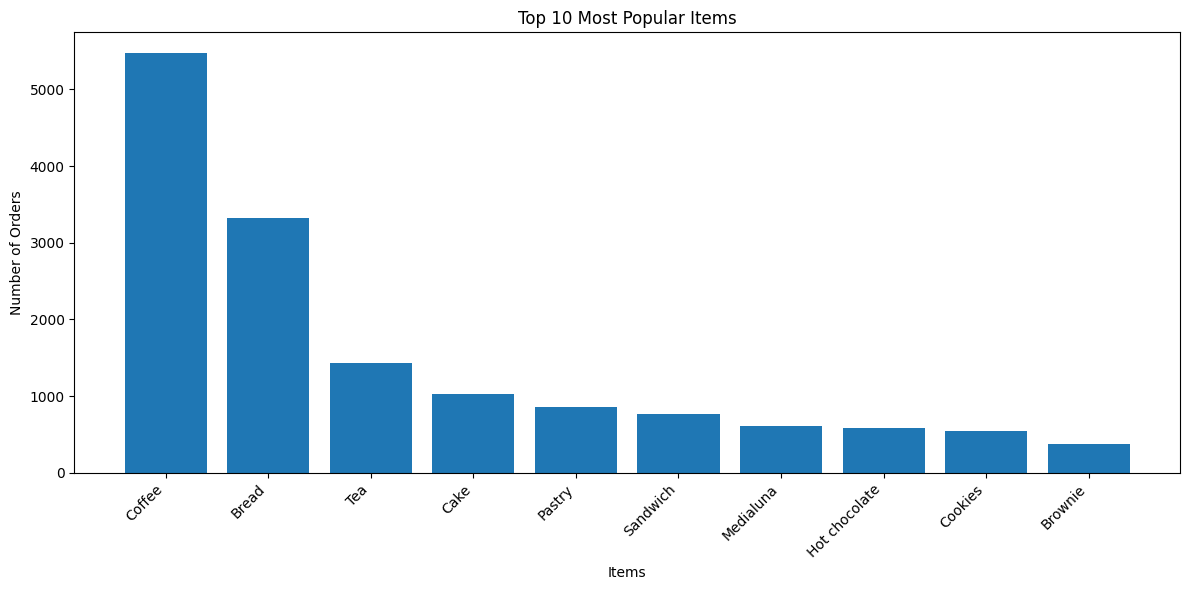

In [14]:
# 19
item_counts = df['Item'].value_counts().reset_index()
item_counts.columns = ['Item', 'Frequency']

top_10_items = item_counts.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_10_items['Item'], top_10_items['Frequency'])
plt.title('Top 10 Most Popular Items')
plt.xlabel('Items')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Hmm, but this is overall data. I want to create a visualization by period instead, maybe the highest sales vary by period.

/tmp/ipykernel_8254/812138692.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm_r')


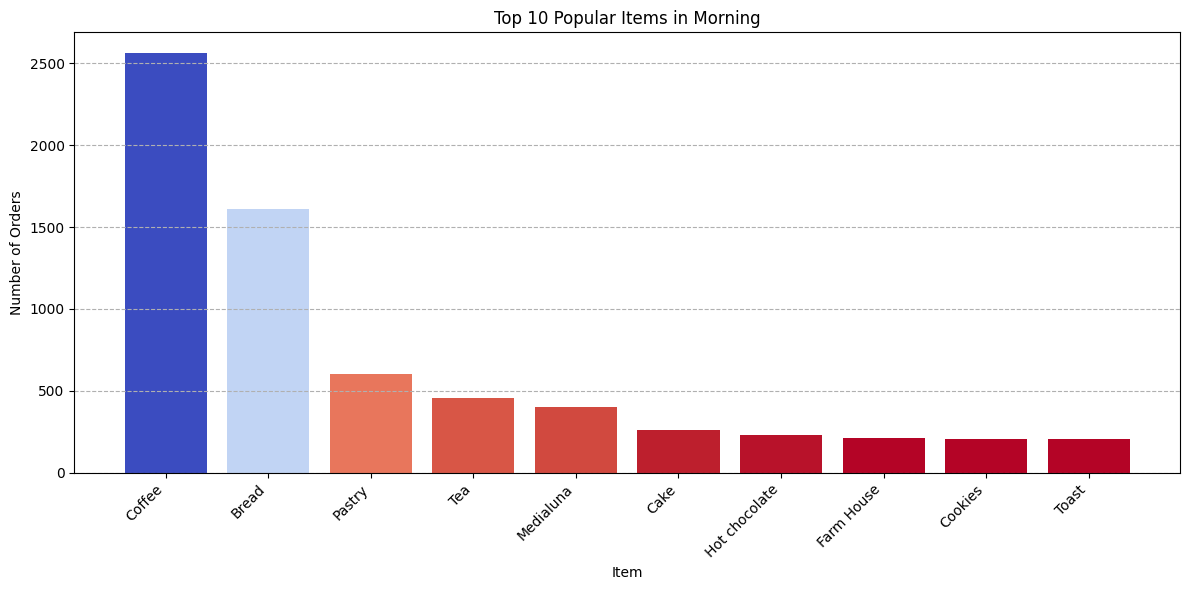

/tmp/ipykernel_8254/812138692.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm_r')


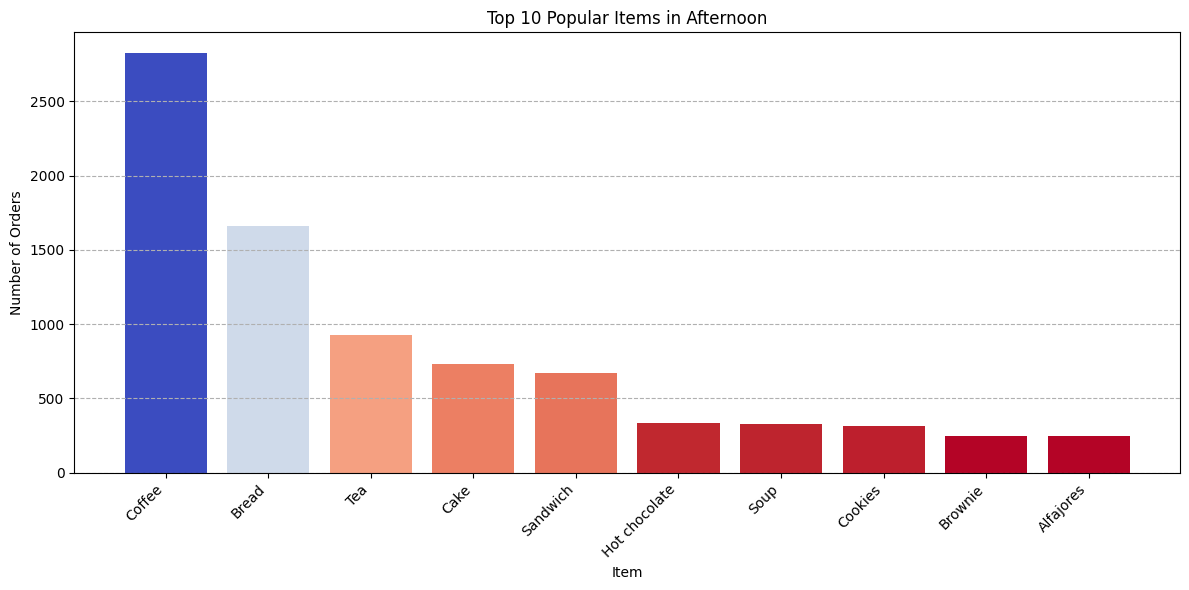

/tmp/ipykernel_8254/812138692.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm_r')


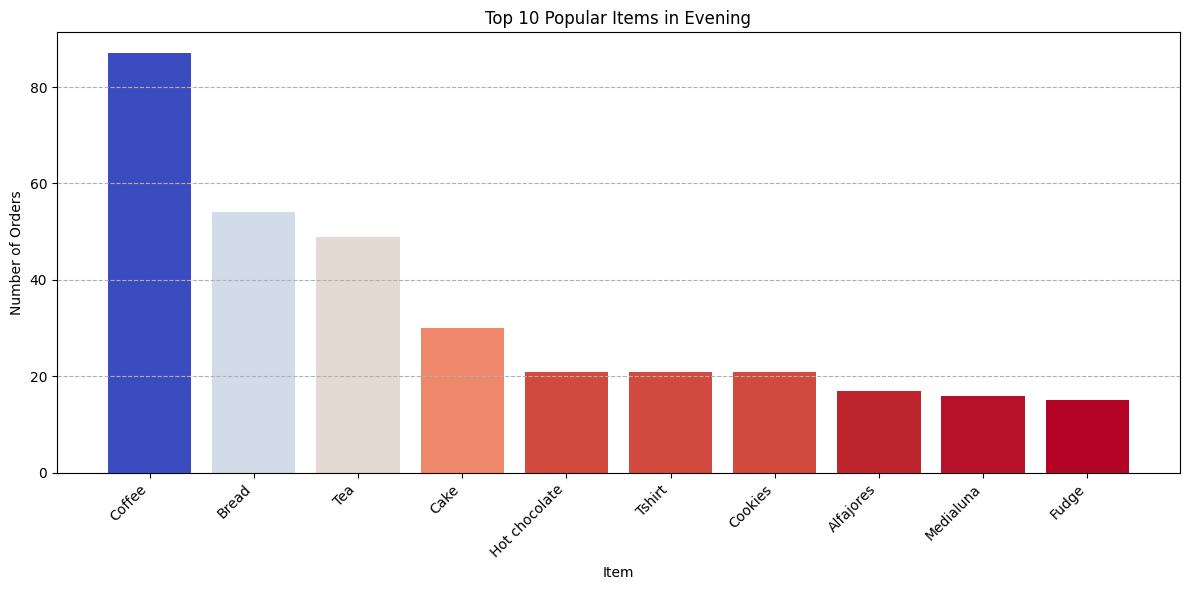

/tmp/ipykernel_8254/812138692.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm_r')


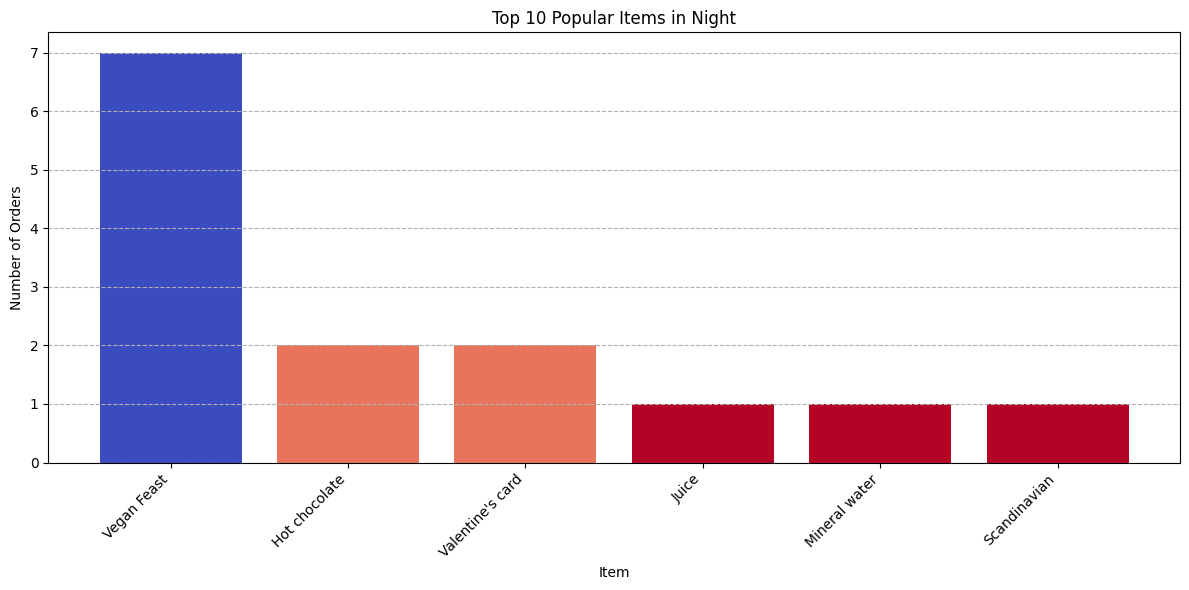

In [15]:
#20
# Morning
period_df = df[df['period_day'] == 'morning']
top_items = period_df['Item'].value_counts().drop(labels=['NONE'], errors='ignore').head(10)

plt.figure(figsize=(12, 6))
if not top_items.empty:
    norm = plt.Normalize(vmin=top_items.min(), vmax=top_items.max())
    cmap = plt.cm.get_cmap('coolwarm_r')
    colors = [cmap(norm(value)) for value in top_items.values]
else:
    colors = ['lightcoral']
plt.bar(top_items.index, top_items.values, color=colors)
plt.title('Top 10 Popular Items in Morning')
plt.xlabel('Item')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()


# Afternoon
period_df = df[df['period_day'] == 'afternoon']
top_items = period_df['Item'].value_counts().drop(labels=['NONE'], errors='ignore').head(10)

plt.figure(figsize=(12, 6))
if not top_items.empty:
    norm = plt.Normalize(vmin=top_items.min(), vmax=top_items.max())
    cmap = plt.cm.get_cmap('coolwarm_r')
    colors = [cmap(norm(value)) for value in top_items.values]
else:
    colors = ['lightcoral']
plt.bar(top_items.index, top_items.values, color=colors)
plt.title('Top 10 Popular Items in Afternoon')
plt.xlabel('Item')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()


# Evening
period_df = df[df['period_day'] == 'evening']
top_items = period_df['Item'].value_counts().drop(labels=['NONE'], errors='ignore').head(10)

plt.figure(figsize=(12, 6))
if not top_items.empty:
    norm = plt.Normalize(vmin=top_items.min(), vmax=top_items.max())
    cmap = plt.cm.get_cmap('coolwarm_r')
    colors = [cmap(norm(value)) for value in top_items.values]
else:
    colors = ['lightcoral']
plt.bar(top_items.index, top_items.values, color=colors)
plt.title('Top 10 Popular Items in Evening')
plt.xlabel('Item')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Night
period_df = df[df['period_day'] == 'night']
top_items = period_df['Item'].value_counts().drop(labels=['NONE'], errors='ignore').head(10)

plt.figure(figsize=(12, 6))
if not top_items.empty:
    norm = plt.Normalize(vmin=top_items.min(), vmax=top_items.max())
    cmap = plt.cm.get_cmap('coolwarm_r')
    colors = [cmap(norm(value)) for value in top_items.values]
else:
    colors = ['lightcoral']
plt.bar(top_items.index, top_items.values, color=colors)
plt.title('Top 10 Popular Items in Night')
plt.xlabel('Item')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

21. It turns out that there is something different in the plot above, the insight is ____


From the bar charts showing top items by period, several distinct patterns emerge:

- Morning: Dominated by breakfast staples. 'Coffee' and 'Bread' are overwhelmingly the most popular, followed by 'Cake', 'Tea', and 'Pastry'. This indicates typical breakfast and early morning snack preferences.
- Afternoon: 'Coffee' remains highly popular, but there's an increase in variety. 'Sandwich', 'Cake', and 'Cookies' see significant popularity, suggesting customers are looking for lunch, a quick bite, or a treat.
- Evening: There's a shift towards comfort and dessert items. 'Hot chocolate' becomes more prominent, along with 'Cake', 'Coffee', and 'Tea', indicating a preference for warm beverages and sweets as the day winds down.
- Night: Transaction volumes are generally much lower. While 'Coffee', 'Hot chocolate', and 'Cake' are still present, other less frequent items like 'Vegan Feast', 'Valentine's card', 'Juice', 'Mineral water', and 'Scandinavian' appear in the top list.

This suggests that night sales are sparse and cater to very specific or niche demands, or perhaps individual larger purchases. The overall frequency of items sold is significantly lower compared to other periods.
In essence, 'Coffee' and 'Cake' are strong sellers throughout the day, but the supporting top items change considerably with the time of day, reflecting different customer needs and occasions.



I found a valentine card, I was curious about when people bought it so I made a visualization of it

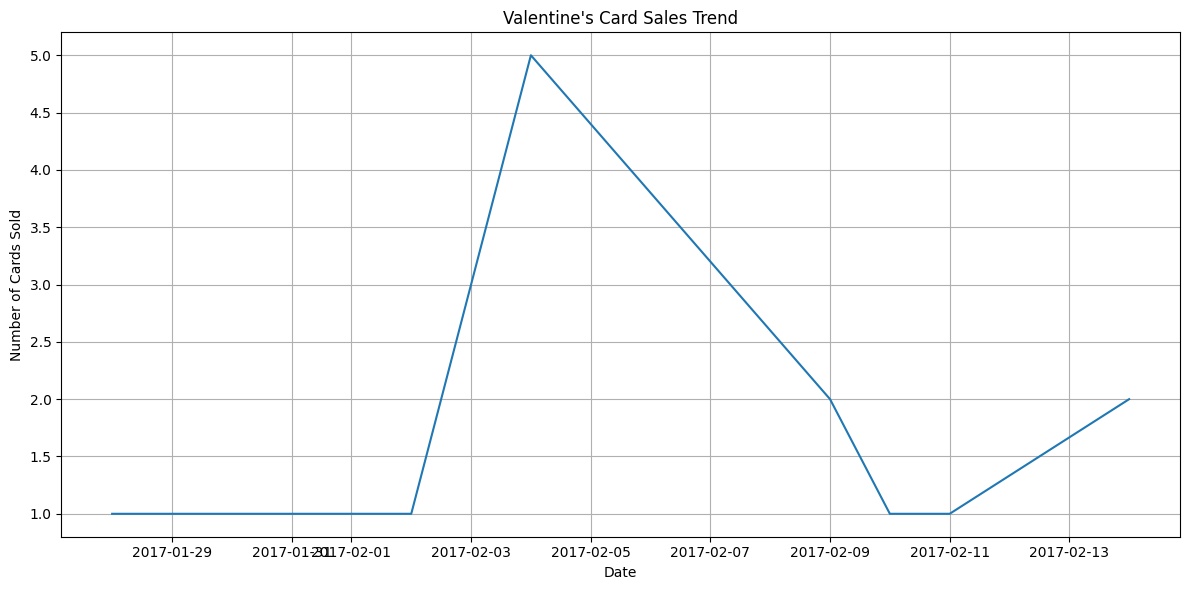

In [16]:
#22
valentine_sales = df[df['Item'] == "Valentine's card"]
valentine_sales_daily = valentine_sales.groupby(valentine_sales['date_time'].dt.date).size()

plt.figure(figsize=(12, 6))
valentine_sales_daily.plot(kind='line', linestyle='-')
plt.title("Valentine's Card Sales Trend")
plt.xlabel('Date')
plt.ylabel('Number of Cards Sold')
plt.grid(True)
plt.tight_layout()
plt.show()

23. I found the insight from the sale of the Valentine's cards above is ____


From the sales trend of Valentine's cards, it's very clear that sales are highly concentrated around mid-February, particularly leading up to Valentine's Day (February 14th). The data shows a significant increase in purchases during this period, highlighting its strong seasonal demand.

## **Applying the Apriori Algorithm**
With a solid understanding of the data, I shift my focus to identifying associations between items using the Apriori algorithm.

### **Data Preparation for Apriori**
I need to transform the dataset into a format suitable for the Apriori algorithm, where each transaction is represented as a row and each item as a column.

In [17]:
# 24

basket = (df[df['Item'] != 'NONE']
          .groupby(['Transaction', 'Item'])['Item']
          .count().unstack().reset_index().fillna(0)
          .set_index('Transaction'))

# Display the first few rows of the prepared data
basket.head()

Item,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
Transaction,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
#25

# Convert quantities to 1 and 0
basket_encoded = basket.applymap(lambda x: 1 if x > 0 else 0)
basket_encoded.head()

/tmp/ipykernel_8254/3237332686.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_encoded = basket.applymap(lambda x: 1 if x > 0 else 0)


Item,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
Transaction,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### **Finding Frequent Itemsets**
Now, I apply the Apriori algorithm to find frequent itemsets with a minimum support threshold. This will help identify combinations of items that are frequently purchased together. Apriori: (min_support=0.02), Association Rules: (metric="lift", min_threshold=1)

In [19]:
#26
frequent_itemsets = apriori(basket_encoded, min_support=0.02, use_colnames=True)
display(frequent_itemsets)

/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:109: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.036344,(Alfajores)
1,0.327205,(Bread)
2,0.040042,(Brownie)
3,0.103856,(Cake)
4,0.478394,(Coffee)
5,0.054411,(Cookies)
6,0.039197,(Farm House)
7,0.058320,(Hot chocolate)
8,0.038563,(Juice)
9,0.061807,(Medialuna)


In [20]:
#27
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# Calculate Jaccard
rules['jaccard'] = rules['support'] / (rules['antecedent support'] + rules['consequent support'] - rules['support'])

# Certainty is typically equivalent to Confidence
rules['certainty'] = rules['confidence']

# Calculate Kulczynski
# confidence(C->A) = support(A U C) / support(C)
rules['kulczynski'] = 0.5 * (rules['confidence'] + (rules['support'] / rules['consequent support']))

# Display the rules with the new metrics, sorted by lift
display(rules.sort_values(by='lift', ascending=False))

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
4,(Tea),(Cake),0.142631,0.103856,0.023772,0.166667,1.604781,0.008959,1.075372,0.439556,0.106736,0.166667,0.197779
5,(Cake),(Tea),0.103856,0.142631,0.023772,0.228891,1.604781,0.008959,1.111865,0.420538,0.106736,0.228891,0.197779
18,(Coffee),(Toast),0.478394,0.033597,0.023666,0.049470,1.472431,0.007593,1.016699,0.615122,0.048464,0.049470,0.376936
19,(Toast),(Coffee),0.033597,0.478394,0.023666,0.704403,1.472431,0.007593,1.764582,0.332006,0.048464,0.704403,0.376936
13,(Medialuna),(Coffee),0.061807,0.478394,0.035182,0.569231,1.189878,0.005614,1.210871,0.170091,0.069665,0.569231,0.321387
12,(Coffee),(Medialuna),0.478394,0.061807,0.035182,0.073542,1.189878,0.005614,1.012667,0.305936,0.069665,0.073542,0.321387
14,(Coffee),(Pastry),0.478394,0.086107,0.047544,0.099382,1.154168,0.006351,1.014740,0.256084,0.091968,0.099382,0.325764
15,(Pastry),(Coffee),0.086107,0.478394,0.047544,0.552147,1.154168,0.006351,1.164682,0.146161,0.091968,0.552147,0.325764
11,(Juice),(Coffee),0.038563,0.478394,0.020602,0.534247,1.116750,0.002154,1.119919,0.108738,0.041507,0.534247,0.288656
10,(Coffee),(Juice),0.478394,0.038563,0.020602,0.043065,1.116750,0.002154,1.004705,0.200428,0.041507,0.043065,0.288656


## Conclusion: The Impact of Data Analysis
28. As my day of analysis comes to a close, I compile my findings into a comprehensive report that highlights several key insights derived from The Bread Basket dataset:



As my day of analysis comes to a close, I've compiled a comprehensive report highlighting several key insights derived from The Bread Basket dataset:

1. Transaction Trends & Peak Times:

Monthly sales showed a significant peak in November 2016, remaining robust through March 2017, with a notable decline in April 2017.
Weekends, especially Saturdays and Sundays, consistently showed the highest transaction volumes, indicating they are the busiest days.
Hourly analysis revealed that transactions consistently peak between 10 AM and 12 PM across most days. The bakery's operational hours primarily span from 7 AM to 8 PM.
2. Item Popularity & Period-Specific Demand:

Overall, 'Coffee', 'Bread', and 'Tea' were the most popular items.
Item popularity varies significantly by period: 'Coffee' and 'Bread' dominate the morning. The afternoon sees increased variety with 'Sandwiches' and 'Cookies'. The evening shifts towards comfort items like 'Hot chocolate' and 'Cake'. Night sales are much lower and cater to specific or niche demands.
3. Seasonal Products:

Sales of 'Valentine's card' were highly concentrated around mid-February, demonstrating strong seasonal demand.
4. Association Rules (Apriori Algorithm):

The Apriori algorithm revealed strong associations between items, particularly with 'Coffee' being frequently purchased alongside many other products (e.g., 'Toast', 'Medialuna', 'Pastry', 'Juice', 'Sandwich', 'Cake', 'Cookies', 'Hot chocolate'). This suggests 'Coffee' is a core item that potentially drives sales of other products.
Other significant associations include 'Cake' and 'Tea', and 'Bread' and 'Pastry'.
These insights can help the bakery optimize its offerings, plan staffing, and tailor marketing strategies to different times of the day and year.